In [1]:
import numpy as np
import pandas as pd
import nltk
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('IMDB Dataset.csv',encoding='latin-1')

In [3]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
data.describe

<bound method NDFrame.describe of                                                   review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
49995  I thought this movie did a down right good job...  positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  negative
49997  I am a Catholic taught in parochial elementary...  negative
49998  I'm going to have to disagree with the previou...  negative
49999  No one expects the Star Trek movies to be high...  negative

[50000 rows x 2 columns]>

In [7]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

In [8]:
data.duplicated().sum()

418

In [9]:
duplicate_rows = data[data.duplicated()]
print(duplicate_rows)

                                                  review sentiment
3537   Quite what the producers of this appalling ada...  negative
3769   My favourite police series of all time turns t...  positive
4391   Beautiful film, pure Cassavetes style. Gena Ro...  positive
6352   If you liked the Grinch movie... go watch that...  negative
6479   I want very much to believe that the above quo...  negative
...                                                  ...       ...
49912  This is an incredible piece of drama and power...  positive
49950  This was a very brief episode that appeared in...  negative
49984  Hello it is I Derrick Cannon and I welcome you...  negative
49986  This movie is a disgrace to the Major League F...  negative
49991  Les Visiteurs, the first movie about the medie...  negative

[418 rows x 2 columns]


In [10]:
data_cleaned = data.drop_duplicates()

In [11]:
data_cleaned

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [12]:
from nltk.tokenize import word_tokenize

In [13]:
data_cleaned['tokenized_reviews'] = data_cleaned['review'].apply(word_tokenize)

In [15]:
from nltk.stem import PorterStemmer

In [16]:
ps = PorterStemmer()

In [17]:
ps

<PorterStemmer>

In [18]:
stemmed_messages = []
for tokens in data_cleaned['tokenized_reviews']:
    stemmed_tokens = []
    for token in tokens:
        stemmed_tokens.append(ps.stem(token))
    stemmed_messages.append(stemmed_tokens)

In [19]:
stemmed_messages

[['one',
  'of',
  'the',
  'other',
  'review',
  'ha',
  'mention',
  'that',
  'after',
  'watch',
  'just',
  '1',
  'oz',
  'episod',
  'you',
  "'ll",
  'be',
  'hook',
  '.',
  'they',
  'are',
  'right',
  ',',
  'as',
  'thi',
  'is',
  'exactli',
  'what',
  'happen',
  'with',
  'me.',
  '<',
  'br',
  '/',
  '>',
  '<',
  'br',
  '/',
  '>',
  'the',
  'first',
  'thing',
  'that',
  'struck',
  'me',
  'about',
  'oz',
  'wa',
  'it',
  'brutal',
  'and',
  'unflinch',
  'scene',
  'of',
  'violenc',
  ',',
  'which',
  'set',
  'in',
  'right',
  'from',
  'the',
  'word',
  'go',
  '.',
  'trust',
  'me',
  ',',
  'thi',
  'is',
  'not',
  'a',
  'show',
  'for',
  'the',
  'faint',
  'heart',
  'or',
  'timid',
  '.',
  'thi',
  'show',
  'pull',
  'no',
  'punch',
  'with',
  'regard',
  'to',
  'drug',
  ',',
  'sex',
  'or',
  'violenc',
  '.',
  'it',
  'is',
  'hardcor',
  ',',
  'in',
  'the',
  'classic',
  'use',
  'of',
  'the',
  'word.',
  '<',
  'br',
  '/',

In [20]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [21]:
data_cleaned['stemmed_reviews'] = stemmed_messages

In [22]:
data_cleaned

,review,sentiment,tokenized_reviews,stemmed_reviews
0,One of the other reviewers has mentioned that ...,positive,"[One, of, the, other, reviewers, has, mentione...","[one, of, the, other, review, ha, mention, tha..."
1,A wonderful little production. <br /><br />The...,positive,"[A, wonderful, little, production, ., <, br, /...","[a, wonder, littl, product, ., <, br, /, >, <,..."
2,I thought this was a wonderful way to spend ti...,positive,"[I, thought, this, was, a, wonderful, way, to,...","[i, thought, thi, wa, a, wonder, way, to, spen..."
3,Basically there's a family where a little boy ...,negative,"[Basically, there, 's, a, family, where, a, li...","[basic, there, 's, a, famili, where, a, littl,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[Petter, Mattei, 's, ``, Love, in, the, Time, ...","[petter, mattei, 's, ``, love, in, the, time, ..."
...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,"[I, thought, this, movie, did, a, down, right,...","[i, thought, thi, movi, did, a, down, right, g..."
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,"[Bad, plot, ,, bad, dialogue, ,, bad, acting, ...","[bad, plot, ,, bad, dialogu, ,, bad, act, ,, i..."
49997,I am a Catholic taught in parochial elementary...,negative,"[I, am, a, Catholic, taught, in, parochial, el...","[i, am, a, cathol, taught, in, parochi, elemen..."
49998,I'm going to have to disagree with the previou...,negative,"[I, 'm, going, to, have, to, disagree, with, t...","[i, 'm, go, to, have, to, disagre, with, the, ..."


In [23]:
from nltk.corpus import stopwords

In [24]:
stop_words = set(stopwords.words('english'))

In [25]:
cleaned_data = []

In [26]:
for words in data_cleaned['stemmed_reviews']:
    filtered_words = []
    for word in words:
        if word not in stop_words:
            filtered_words.append(word)
    cleaned_data.append(' '.join(filtered_words))

In [27]:
cleaned_data

["one review ha mention watch 1 oz episod 'll hook . right , thi exactli happen me. < br / > < br / > first thing struck oz wa brutal unflinch scene violenc , set right word go . trust , thi show faint heart timid . thi show pull punch regard drug , sex violenc . hardcor , classic use word. < br / > < br / > call oz nicknam given oswald maximum secur state penitentari . focus mainli emerald citi , experiment section prison cell glass front face inward , privaci high agenda . em citi home mani .. aryan , muslim , gangsta , latino , christian , italian , irish .... scuffl , death stare , dodgi deal shadi agreement never far away. < br / > < br / > would say main appeal show due fact goe show would n't dare . forget pretti pictur paint mainstream audienc , forget charm , forget romanc ... oz doe n't mess around . first episod ever saw struck nasti wa surreal , could n't say wa readi , watch , develop tast oz , got accustom high level graphic violenc . violenc , injustic ( crook guard 'll 

In [28]:
data_cleaned['cleaned_reviews'] = cleaned_data

In [29]:
data_cleaned

,review,sentiment,tokenized_reviews,stemmed_reviews,cleaned_reviews
0,One of the other reviewers has mentioned that ...,positive,"[One, of, the, other, reviewers, has, mentione...","[one, of, the, other, review, ha, mention, tha...",one review ha mention watch 1 oz episod 'll ho...
1,A wonderful little production. <br /><br />The...,positive,"[A, wonderful, little, production, ., <, br, /...","[a, wonder, littl, product, ., <, br, /, >, <,...",wonder littl product . < br / > < br / > film ...
2,I thought this was a wonderful way to spend ti...,positive,"[I, thought, this, was, a, wonderful, way, to,...","[i, thought, thi, wa, a, wonder, way, to, spen...",thought thi wa wonder way spend time hot summe...
3,Basically there's a family where a little boy ...,negative,"[Basically, there, 's, a, family, where, a, li...","[basic, there, 's, a, famili, where, a, littl,...",basic 's famili littl boy ( jake ) think 's zo...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[Petter, Mattei, 's, ``, Love, in, the, Time, ...","[petter, mattei, 's, ``, love, in, the, time, ...",petter mattei 's `` love time money '' visual ...
...,...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,"[I, thought, this, movie, did, a, down, right,...","[i, thought, thi, movi, did, a, down, right, g...",thought thi movi right good job . wa n't creat...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,"[Bad, plot, ,, bad, dialogue, ,, bad, acting, ...","[bad, plot, ,, bad, dialogu, ,, bad, act, ,, i...","bad plot , bad dialogu , bad act , idiot direc..."
49997,I am a Catholic taught in parochial elementary...,negative,"[I, am, a, Catholic, taught, in, parochial, el...","[i, am, a, cathol, taught, in, parochi, elemen...","cathol taught parochi elementari school nun , ..."
49998,I'm going to have to disagree with the previou...,negative,"[I, 'm, going, to, have, to, disagree, with, t...","[i, 'm, go, to, have, to, disagre, with, the, ...",'m go disagre previou comment side maltin thi ...


In [30]:
new = []

for x in data_cleaned:
    if x not in stop_words:
        new.append(x)

In [31]:
new

['review',
 'sentiment',
 'tokenized_reviews',
 'stemmed_reviews',
 'cleaned_reviews']

In [32]:
data_cleaned

,review,sentiment,tokenized_reviews,stemmed_reviews,cleaned_reviews
0,One of the other reviewers has mentioned that ...,positive,"[One, of, the, other, reviewers, has, mentione...","[one, of, the, other, review, ha, mention, tha...",one review ha mention watch 1 oz episod 'll ho...
1,A wonderful little production. <br /><br />The...,positive,"[A, wonderful, little, production, ., <, br, /...","[a, wonder, littl, product, ., <, br, /, >, <,...",wonder littl product . < br / > < br / > film ...
2,I thought this was a wonderful way to spend ti...,positive,"[I, thought, this, was, a, wonderful, way, to,...","[i, thought, thi, wa, a, wonder, way, to, spen...",thought thi wa wonder way spend time hot summe...
3,Basically there's a family where a little boy ...,negative,"[Basically, there, 's, a, family, where, a, li...","[basic, there, 's, a, famili, where, a, littl,...",basic 's famili littl boy ( jake ) think 's zo...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[Petter, Mattei, 's, ``, Love, in, the, Time, ...","[petter, mattei, 's, ``, love, in, the, time, ...",petter mattei 's `` love time money '' visual ...
...,...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,"[I, thought, this, movie, did, a, down, right,...","[i, thought, thi, movi, did, a, down, right, g...",thought thi movi right good job . wa n't creat...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,"[Bad, plot, ,, bad, dialogue, ,, bad, acting, ...","[bad, plot, ,, bad, dialogu, ,, bad, act, ,, i...","bad plot , bad dialogu , bad act , idiot direc..."
49997,I am a Catholic taught in parochial elementary...,negative,"[I, am, a, Catholic, taught, in, parochial, el...","[i, am, a, cathol, taught, in, parochi, elemen...","cathol taught parochi elementari school nun , ..."
49998,I'm going to have to disagree with the previou...,negative,"[I, 'm, going, to, have, to, disagree, with, t...","[i, 'm, go, to, have, to, disagre, with, the, ...",'m go disagre previou comment side maltin thi ...


In [33]:
from sklearn.feature_extraction.text import CountVectorizer

In [34]:
vectorizer = CountVectorizer()

In [35]:
vectorizer

CountVectorizer()

In [36]:
bow_features = vectorizer.fit_transform(cleaned_data)

In [37]:
bow_features

<49582x81994 sparse matrix of type '<class 'numpy.int64'>'
	with 4969475 stored elements in Compressed Sparse Row format>

In [38]:
50000-418

49582

First 5 rows:
                                               review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Describe:
                                                    review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive


C:\Users\91971\AppData\Local\Temp\ipykernel_17396\4203028151.py:28: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text()  # Remove HTML
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91971\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Tokenizing, removing stopwords, and stemming...
Extracting features with TF-IDF...
Training Logistic Regression...

Accuracy: 0.8879477250726041

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89      6175
           1       0.88      0.90      0.89      6221

    accuracy                           0.89     12396
   macro avg       0.89      0.89      0.89     12396
weighted avg       0.89      0.89      0.89     12396


Confusion Matrix:
 [[5400  775]
 [ 614 5607]]


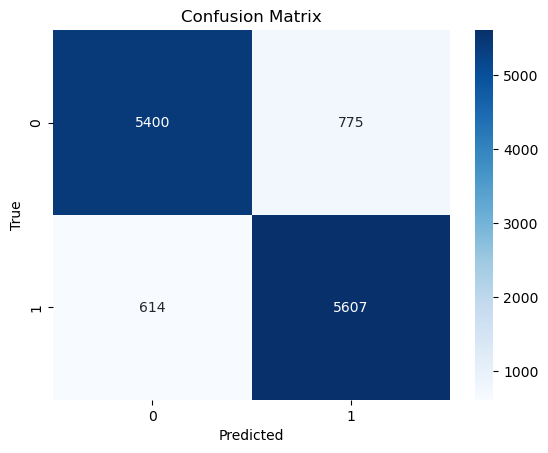

In [4]:
# imdb_sentiment_analysis.py
import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_inspect_data(path):
    df = pd.read_csv(path)
    print("First 5 rows:\n", df.head())
    print("\nData info:")
    print(df.info())
    print("\nDescribe:\n", df.describe())
    print("\nNull values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    df = df.drop_duplicates()
    return df

def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()  # Remove HTML
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)   # Remove URLs
    text = text.lower()                                   # Lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)               # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()              # Remove extra spaces
    return text

def preprocess_text(df):
    print("Cleaning text...")
    df['cleaned_review'] = df['review'].apply(clean_text)
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    def tokenize_and_stem(text):
        tokens = text.split()
        cleaned = [stemmer.stem(word) for word in tokens if word not in stop_words]
        return ' '.join(cleaned)
    print("Tokenizing, removing stopwords, and stemming...")
    df['preprocessed_review'] = df['cleaned_review'].apply(tokenize_and_stem)
    return df

def feature_extraction(df):
    print("Extracting features with TF-IDF...")
    tfidf = TfidfVectorizer(max_features=10000)
    X = tfidf.fit_transform(df['preprocessed_review'])
    df['sentiment_num'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
    y = df['sentiment_num'].values
    return X, y

def train_and_evaluate(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y)
    print("Training Logistic Regression...")
    model = LogisticRegression(max_iter=300)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    # Plot Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

if __name__ == "__main__":
    df = load_and_inspect_data("IMDB Dataset.csv")
    df = preprocess_text(df)
    X, y = feature_extraction(df)
    train_and_evaluate(X, y)
